# Noise reduction !!!WARNING THIS TAKES A LOT OF RAM AND MIGHT CRASH YOUR PC!!!

I have 16gb and had to close everything else so i don't crash (sorry)

The goal of this notebook is to reduce noise amongst all data files using a noise reduction library and plot the results.
The setup is this:
1. Go through all sound files in `./data`
2. Load the raw signal
3. Load part of the raw signal a noise reference data
4. Reduce noise through use of a library
5. Generate spectogram for resulting waveform
6. Store spectogram and noise-reduced audio in `./wave_forms_denoised` and `./data_denoised` respectively

First, let's import all the necessary libraries:

In [1]:
import soundfile as sf          # Loads audio files from memory
import noisereduce as nr        # Can reduce noise in audio buffers
import numpy as np              # Needed for audio compression
import os                       # OS interface
import matplotlib.pyplot as plt # Plots denoised audio files

We will declare some constants and get a list of all data files:

In [2]:
DATA_DIR = "../data/wav"
DENOISED_WAVE_FORM_DIR = "wave_forms_denoised"
DENOISED_DIR = "./data_denoised"
wav_file_paths = sorted(os.listdir(DATA_DIR))

This function loads in unfiltered data from our `.wav`-files:

In [3]:
def get_signal(path: str) -> np.ndarray:
    signal, sample_rate = sf.read(f"{DATA_DIR}/{path}")
    return signal, sample_rate

This is where the magic happens.

- Used `get_signal()` to load the data
- Naively assume first 10% of data is always noise
- Use "noisereduce" library to reduce noise
    - 99% reduction rate (`prop_decrease`)
    - Assume noise is unchanged within one file (`stationary`)
    - Relatively lenient noise reduction (`n_std_thresh_stationary`)
- Smooth out noise to remove unpleasant peaks (`np.tanh`) (since we have a lot of silence and SUPER loud parts i.e. when the hydrophone is being moved)
- Return amplified + denoised signal

In [4]:
def get_denoised_signal(path: str, amp: int = 5):
    noise_reference_signal, sample_rate = get_signal(path)
    noise_lim = int(len(noise_reference_signal)/10)
    noise_sample = noise_reference_signal[:noise_lim]

    audio_data, _ = get_signal(path)

    reduced_noise_audio = nr.reduce_noise(n_jobs=-1, y=audio_data, sr=sample_rate, y_noise=noise_sample, prop_decrease=0.999, stationary=True, n_std_thresh_stationary=4.0)

    compressed_audio = np.tanh(reduced_noise_audio * 1.5)
    max_peak = np.max(np.abs(compressed_audio))
    if max_peak > 0:
        reduced_noise_audio = (compressed_audio / max_peak) * 1.0

    return reduced_noise_audio * amp, sample_rate

Finally, go through all files, denoise them and store both the waveform spectrogram and raw in their respective folders (may take some time to run):

In [5]:
signals = []
for i, wav_file_path in enumerate(wav_file_paths):
    time_stamp = wav_file_path.split("_")[-1].split(".")[0]
    print(time_stamp)
    # Since the process takes so long we want to be able to pick it up where we left of last time
    if time_stamp != "102000" and time_stamp != "103000" and time_stamp != "104000":
        print(f"Skipping {i}")
        continue
    print(f"Generating wave file: {time_stamp} #{i}/{len(wav_file_paths)}")
    signal, sample_rate = get_denoised_signal(wav_file_path)
    signals.append(signal)
    #plt.specgram(signal)
    #plt.xlabel('Frame index (time)'); plt.ylabel('Frequency (normalized)')
    #plt.savefig(f"{DENOISED_WAVE_FORM_DIR}/{time_stamp}.png")
    #sf.write(f"{DENOISED_DIR}/{time_stamp}.wav", signal, sample_rate)

print(len(signals))


083000
Skipping 0
084000
Skipping 1
085000
Skipping 2
090000
Skipping 3
091000
Skipping 4
092000
Skipping 5
093000
Skipping 6
094000
Skipping 7
095000
Skipping 8
100000
Skipping 9
101000
Skipping 10
102000
Generating wave file: 102000 #11/40
103000
Generating wave file: 103000 #12/40
104000
Generating wave file: 104000 #13/40
105000
Skipping 14
110644
Skipping 15
111000
Skipping 16
112000
Skipping 17
113000
Skipping 18
114000
Skipping 19
115000
Skipping 20
120000
Skipping 21
121000
Skipping 22
122000
Skipping 23
123000
Skipping 24
124000
Skipping 25
125000
Skipping 26
130000
Skipping 27
131000
Skipping 28
132000
Skipping 29
133000
Skipping 30
134000
Skipping 31
135000
Skipping 32
140000
Skipping 33
141000
Skipping 34
142000
Skipping 35
143000
Skipping 36
144000
Skipping 37
145000
Skipping 38
150000
Skipping 39
3


57600000


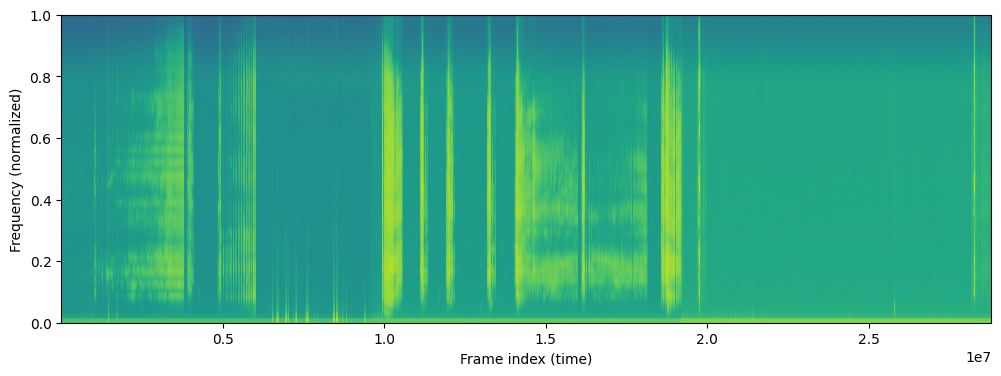

In [6]:
new_signal = list(signals[0]) + list(signals[1]) + list(signals[2])
signals = None
signal = None
print(len(new_signal))

plt.figure(figsize=(12,4))
plt.specgram(new_signal)
plt.xlabel('Frame index (time)'); plt.ylabel('Frequency (normalized)')
#plt.savefig(f"{DENOISED_WAVE_FORM_DIR}/{time_stamp}.png")
plt.savefig("dingsfig")